#Algorithme d'apprentissage - Projet foot

Maximilien BERNARD

## Introduction
Ce notebook présente une étude complète visant à prédire les résultats des matchs de football de la Ligue 1 (championnat de football français de première division) pour la période de 2013 à 2024, avec une prédiction finale pour les matchs de 2025.

## Sommaire
1.  **Chargement et Préparation des Données**
2.  **Division Entraînement-Test**
3.  **Réduction de la Dimensionalité avec ACP**
4.  **Implémentation et Évaluation du Modèle** :
    *   **Random forest**
    *   **SVM**
    *   **KNN**
    *   **Régression Logistique**
5.  **Analyse Comparative**
6.  **Prédiction des Matchs de 2025**

Import Data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_clubs     = pd.read_csv('clubs_fr.csv')
df_matchs    = pd.read_csv('matchs_2013_2024.csv', index_col=0)
df_match2025 = pd.read_csv('match_2025.csv')
df_appear    = pd.read_csv('player_appearance.csv')
df_events    = pd.read_csv('game_events_before2025.csv', index_col=0)
df_lineups   = pd.read_csv('game_lineups.csv', index_col=0, low_memory=False)
df_valuation = pd.read_csv('player_valuation_before_season.csv')
df_sample    = pd.read_csv('sample_results.csv')


#Exploration Qualitative

## distribution historique des matchs

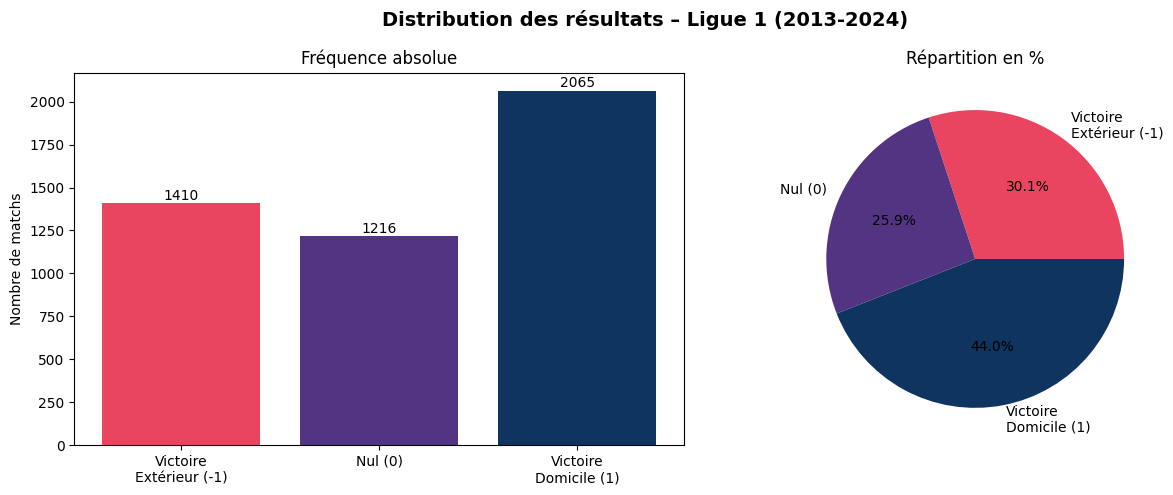

In [ ]:
result_counts = df_matchs['results'].value_counts().sort_index()
labels = {1: 'Victoire\nDomicile (1)', 0: 'Nul (0)', -1: 'Victoire\nExtérieur (-1)'}
colors = ['#e94560', '#533483', '#0f3460']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribution des résultats – Ligue 1 (2013-2024)', fontsize=14, fontweight='bold')

# diagramme baton
bars = axes[0].bar([labels[k] for k in result_counts.index],
                   result_counts.values, color=colors)
axes[0].set_ylabel('Nombre de matchs')
axes[0].set_title('Fréquence absolue')
for bar, val in zip(bars, result_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(val), ha='center')

# camember
axes[1].pie(result_counts.values,
            labels=[labels[k] for k in result_counts.index],
            colors=colors, autopct='%1.1f%%')
axes[1].set_title('Répartition en %')

plt.tight_layout()
plt.show()


si les équipes gagnent dans 44% des cas en jouant à domicile, On cherche donc un modèle ayant plus de 44% de bonne prédiction.

# Affichage de la valeur marchande des joueurs par club juste avant 2025

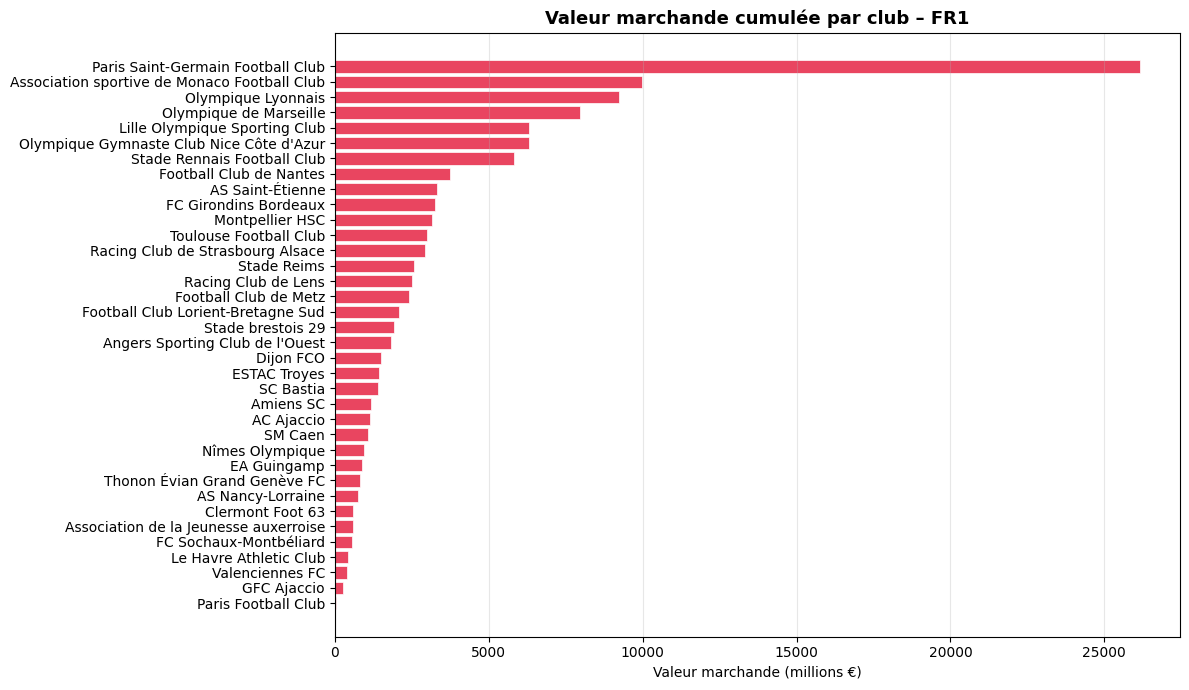

In [ ]:
val_latest = (df_valuation[df_valuation['player_club_domestic_competition_id'] == 'FR1']
              .sort_values('date')
              .groupby('current_club_id')['market_value_in_eur']
              .sum()
              .reset_index()
              .rename(columns={'current_club_id': 'club_id',
                               'market_value_in_eur': 'total_market_value'}))

val_latest = val_latest.merge(df_clubs[['club_id', 'name']], on='club_id', how='left')
val_latest = val_latest.dropna(subset=['name']).sort_values('total_market_value', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(val_latest['name'], val_latest['total_market_value'] / 1e6,
               color='#e94560', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Valeur marchande (millions €)')
ax.set_title('Valeur marchande cumulée par club – FR1', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


###Préparation des données d'entrainements

Ici je prépare les données de chaque équipes avant de les comparer dans mon dataset final

In [ ]:


# 1. Préparation globale des données
df_matchs['date'] = pd.to_datetime(df_matchs['date'])
df_match2025['date'] = pd.to_datetime(df_match2025['date'])
all_matches = pd.concat([df_matchs, df_match2025], sort=False).sort_values('date')

# Encodage des résultats pour les calculs (1=Victoire Dom, 0=Nul, -1=Victoire Ext)
# Calculs des points pour les équipes à l'issus du match : victoire = +3points, égalité = +1point, défaite = 0points
all_matches['home_pts'] = all_matches['results'].map({1: 3, 0: 1, -1: 0})
all_matches['away_pts'] = all_matches['results'].map({1: 0, 0: 1, -1: 3})
# Clacul de la différence de buts entre les équipes (goal diff)
all_matches['home_gd'] = all_matches['home_club_goals'] - all_matches['away_club_goals']
all_matches['away_gd'] = -all_matches['home_gd']

# 2. Calcul des statistiques glissante par équipe
n=5
# On reformate pour avoir une ligne par équipe par match
home = all_matches[['game_id', 'date', 'home_club_id', 'home_pts', 'home_gd']].rename(
    columns={'home_club_id': 'club_id', 'home_pts': 'pts', 'home_gd': 'gd'})
away = all_matches[['game_id', 'date', 'away_club_id', 'away_pts', 'away_gd']].rename(
    columns={'away_club_id': 'club_id', 'away_pts': 'pts', 'away_gd': 'gd'})

team_stats = pd.concat([home, away]).sort_values(['club_id', 'date'])

# Points moyens et Différentiel de buts sur les 5 derniers matchs
# shift(1) est CRUCIAL pour ne pas inclure le match actuel dans sa propre moyenne
group = team_stats.groupby('club_id')
team_stats['rolling_pts'] = group['pts'].transform(lambda x: x.shift(1).rolling(n, min_periods=1).mean())
team_stats['rolling_gd'] = group['gd'].transform(lambda x: x.shift(1).rolling(n, min_periods=1).sum())

# Temps de repos (en jours)
team_stats['last_match_date'] = group['date'].shift(1)
team_stats['rest_days'] = (team_stats['date'] - team_stats['last_match_date']).dt.days
team_stats['rest_days'] = team_stats['rest_days'].fillna(10) # 10 jours par défaut si premier match

stats_rolling = team_stats[['game_id', 'club_id', 'rolling_pts', 'rolling_gd', 'rest_days']]

# 3. Calcul de la valeur de l'équipe (Market Value)
# On simplifie en prenant la somme des valeurs par club et par date
market_values = df_valuation.groupby(['current_club_id', 'date'])['market_value_in_eur'].sum().reset_index()
market_values['date'] = pd.to_datetime(market_values['date'])

# 4. Calcul du Head-to-Head (H2H)
# Créer un identifiant unique pour le duo d'équipes (trié pour que A-B soit identique à B-A)
all_matches['h2h_key'] = all_matches.apply(lambda row: tuple(sorted([row['home_club_id'], row['away_club_id']])), axis=1)

h2h_list = []
for key, group in all_matches.groupby('h2h_key'):
    group = group.sort_values('date')
    # Pour chaque match, on calcule l'historique des matchs précédents entre ces deux-là
    for i in range(len(group)):
        past_matches = group.iloc[:i]
        game_id = group.iloc[i]['game_id']
        home_id = group.iloc[i]['home_club_id']

        if len(past_matches) > 0:
            # Ratio de points pour l'équipe qui reçoit aujourd'hui
            pts_home = past_matches.apply(lambda r: r['home_pts'] if r['home_club_id'] == home_id else r['away_pts'], axis=1).mean()
            # Moyenne de buts marqués par l'hôte contre cet adversaire
            goals_home = past_matches.apply(lambda r: r['home_club_goals'] if r['home_club_id'] == home_id else r['away_club_goals'], axis=1).mean()
            h2h_list.append({'game_id': game_id, 'h2h_win_ratio': pts_home / 3, 'h2h_avg_goals': goals_home})
        else:
            h2h_list.append({'game_id': game_id, 'h2h_win_ratio': 0.33, 'h2h_avg_goals': 0}) # Valeurs neutres

h2h_stats = pd.DataFrame(h2h_list)

# 5. Assemblage du Dataset Final (df)
df = all_matches[['game_id', 'date', 'home_club_id', 'away_club_id', 'referee', 'home_club_position', 'away_club_position', 'results']].copy()


# Fusion avec les stats de forme (Domicile)
df = df.merge(stats_rolling, left_on=['game_id', 'home_club_id'], right_on=['game_id', 'club_id'], how='left').rename(
    columns={'rolling_pts': 'home_rolling_pts', 'rolling_gd': 'home_rolling_gd', 'rest_days': 'home_rest_days'}).drop('club_id', axis=1)

# Fusion avec les stats de forme (Extérieur)
df = df.merge(stats_rolling, left_on=['game_id', 'away_club_id'], right_on=['game_id', 'club_id'], how='left').rename(
    columns={'rolling_pts': 'away_rolling_pts', 'rolling_gd': 'away_rolling_gd', 'rest_days': 'away_rest_days'}).drop('club_id', axis=1)

# Fusion avec les caractéristiques des clubs (Static)
club_features = df_clubs[['club_id', 'national_team_players', 'average_age', 'foreigners_percentage']]
df = df.merge(club_features, left_on='home_club_id', right_on='club_id', how='left').rename(
    columns={col: 'home_'+col for col in club_features.columns if col != 'club_id'}).drop('club_id', axis=1)
df = df.merge(club_features, left_on='away_club_id', right_on='club_id', how='left').rename(
    columns={col: 'away_'+col for col in club_features.columns if col != 'club_id'}).drop('club_id', axis=1)

# Fusion avec le H2H
df = df.merge(h2h_stats, on='game_id', how='left')

# Suppression des colonnes inutiles et gestion des NaNs
#df = df.drop(['date', 'referee'], axis=1)
df.fillna(0)

print(df.head())

   game_id       date  home_club_id  away_club_id                referee  \
0  2229837 2012-08-10           969           415         Antony Gautier   
1  2229834 2012-08-11         14171            40         Benoît Bastien   
2  2229835 2012-08-11           750           595  Jean-Charles Cailleux   
3  2229836 2012-08-11           273          1041      Nicolas Rainville   
4  2229839 2012-08-11           583          1158           Tony Chapron   

   home_club_position  away_club_position  results  home_rolling_pts  \
0                12.0                11.0      0.0               NaN   
1                14.0                 1.0     -1.0               NaN   
2                13.0                 2.0     -1.0               NaN   
3                16.0                 5.0     -1.0               NaN   
4                 9.0                10.0      0.0               NaN   

   home_rolling_gd  ...  away_rolling_gd  away_rest_days  \
0              NaN  ...              NaN          

Création du dataset final avec les écarts entre les équipes et non les valeurs de chaque équipes

In [ ]:
# 1. Préparation de la valeur marchande (si pas déjà fait)
# On récupère la valeur la plus récente par club
current_valuation = df_valuation.sort_values('date').groupby('current_club_id').last()[['market_value_in_eur']]

# On ajoute ces valeurs au dataframe principal avant de calculer les écarts
df = df.merge(current_valuation, left_on='home_club_id', right_index=True, how='left').rename(columns={'market_value_in_eur': 'home_value'})
df = df.merge(current_valuation, left_on='away_club_id', right_index=True, how='left').rename(columns={'market_value_in_eur': 'away_value'})

# 2. Création du dataframe df_final
df_final = pd.DataFrame()

# Identifiants et Cible
df_final['game_id'] = df['game_id']
df_final['date'] = df['date']
df_final['target_results'] = df['results'] # La colonne à prédire

# Calcul des Écarts (Domicile - Extérieur)
# Un résultat positif signifie que l'avantage est à l'équipe à domicile
df_final['ecart_pts_moyens'] = df['home_rolling_pts'] - df['away_rolling_pts']
df_final['ecart_gd_recent'] = df['home_rolling_gd'] - df['away_rolling_gd']
df_final['ecart_repos'] = df['home_rest_days'] - df['away_rest_days']
df_final['ecart_valeur_totale'] = df['home_value'] - df['away_value']
df_final['ecart_internationaux'] = df['home_national_team_players'] - df['away_national_team_players']
df_final['ecart_age_moyen'] = df['home_average_age'] - df['away_average_age']
df_final['ecart_pourcentage_etrangers'] = df['home_foreigners_percentage'] - df['away_foreigners_percentage']

# Attention : pour le classement, un chiffre plus PETIT est MEILLEUR (1er > 10ème)
df_final['ecart_classement'] = df['away_club_position'] - df['home_club_position']  # Si c'est positif ; équipe à domicile est mieux classée.

# Statistiques H2H (déjà calculées précédemment)
df_final['h2h_dominance_ratio'] = df['h2h_win_ratio']
df_final['h2h_moyenne_buts'] = df['h2h_avg_goals']

# Nettoyage final des NaNs au cas où
df_final = df_final.fillna(0)


print("Aperçu du dataset prêt pour le Random Forest :")
print(df_final.head())

Aperçu du dataset prêt pour le Random Forest :
   game_id       date  target_results  ecart_pts_moyens  ecart_gd_recent  \
0  2229837 2012-08-10             0.0               0.0              0.0   
1  2229834 2012-08-11            -1.0               0.0              0.0   
2  2229835 2012-08-11            -1.0               0.0              0.0   
3  2229836 2012-08-11            -1.0               0.0              0.0   
4  2229839 2012-08-11             0.0               0.0              0.0   

   ecart_repos  ecart_valeur_totale  ecart_internationaux  ecart_age_moyen  \
0          0.0             -2500000                    -4              0.2   
1          0.0             -1800000                    -5              4.7   
2          0.0              -600000                    -5             -4.6   
3          0.0             14000000                    -2             -0.1   
4          0.0             39000000                    12             -1.9   

   ecart_pourcentage_etrang

In [ ]:
print(df_final.columns)

Index(['game_id', 'date', 'target_results', 'ecart_pts_moyens',
       'ecart_gd_recent', 'ecart_repos', 'ecart_valeur_totale',
       'ecart_internationaux', 'ecart_age_moyen',
       'ecart_pourcentage_etrangers', 'ecart_classement',
       'h2h_dominance_ratio', 'h2h_moyenne_buts'],
      dtype='object')


### Explication des données de `df_final`

Voici le détail de chaque colonne dans `df_final` et de son calcul :

*   **`game_id`**: Identifiant unique du match. Provient du DataFrame `df`.
*   **`date`**: Date du match. Provient du DataFrame `df`.
*   **`target_results`**: La variable cible à prédire. Il s'agit du résultat du match (1 pour victoire à domicile, 0 pour match nul, -1 pour victoire à l'extérieur), directement issu de la colonne `results` du DataFrame `df`.

#### Colonnes d'Écarts (différences Domicile - Extérieur)
Ces colonnes représentent la différence entre une caractéristique de l'équipe à domicile et la même caractéristique pour l'équipe à l'extérieur. Un résultat positif indique un avantage pour l'équipe à domicile pour cette caractéristique.

*   **`ecart_pts_moyens`**: Écart de points moyens sur les 5 derniers matchs.
    *   Calcul: `df['home_rolling_pts'] - df['away_rolling_pts']`
*   **`ecart_gd_recent`**: Écart de différence de buts sur les 5 derniers matchs.
    *   Calcul: `df['home_rolling_gd'] - df['away_rolling_gd']`
*   **`ecart_repos`**: Écart de jours de repos depuis le dernier match.
    *   Calcul: `df['home_rest_days'] - df['away_rest_days']`
*   **`ecart_valeur_totale`**: Écart de valeur marchande totale du club.
    *   Calcul: `df['home_value'] - df['away_value']`
*   **`ecart_internationaux`**: Écart du nombre de joueurs internationaux.
    *   Calcul: `df['home_national_team_players'] - df['away_national_team_players']`
*   **`ecart_age_moyen`**: Écart de l'âge moyen des joueurs.
    *   Calcul: `df['home_average_age'] - df['away_average_age']`
*   **`ecart_pourcentage_etrangers`**: Écart du pourcentage de joueurs étrangers.
    *   Calcul: `df['home_foreigners_percentage'] - df['away_foreigners_percentage']`
*   **`ecart_classement`**: Écart de position au classement.Un classement plus petit est meilleur. Donc, si `ecart_classement` est positif, cela signifie que l'équipe à domicile est mieux classée.
    *   Calcul: `df['away_club_position'] - df['home_club_position']`

#### Statistiques face à face ( Head-to-Head (H2H))
Ces caractéristiques proviennent directement du calcul H2H agrégé dans le DataFrame `df`, sans calcul d'écart car elles sont déjà relatives à la confrontation spécifique.

*   **`h2h_dominance_ratio`**: Ratio de victoires (ou de points obtenus sur 3) de l'équipe à domicile contre l'équipe à l'extérieur lors de leurs rencontres passées. Une valeur neutre de 0.33 est attribuée s'il n'y a pas d'historique.
*   **`h2h_moyenne_buts`**: Moyenne des buts marqués par l'équipe à domicile contre l'équipe à l'extérieur lors de leurs rencontres passées. Une valeur neutre de 0 est attribuée s'il n'y a pas d'historique.

`df_final` est rempli avec la valeur `0` pour toutes les valeurs manquantes (`NaN`).

##Partie test

Dans cette partie je cherche à prédire les matchs de 2024 à partir des données de 2013 à 2023 afin d'obtenir la meilleur prédiction et déterminer une précision des prédictions ainsi que les meilleurs paramètre pour le random forest.

séparer en X train, Y train, X test et Y test

In [ ]:
X_train = df_final[df_final['date'] < "2024-01-01"].copy()
Y_train = X_train.copy()
X_test = df_final[df_final['date'] >= "2024-01-01"].copy()
X_test = X_test[X_test['date'] < "2025-01-01"].copy()
Y_test = X_test.copy()

X_train = X_train.drop(columns = ['date'])
Y_train = Y_train.drop(columns = ['date', 'ecart_pts_moyens',
       'ecart_gd_recent', 'ecart_repos', 'ecart_valeur_totale',
       'ecart_internationaux', 'ecart_age_moyen',
       'ecart_pourcentage_etrangers', 'ecart_classement',
       'h2h_dominance_ratio', 'h2h_moyenne_buts'])
X_test = X_test.drop(columns = ['date'])
Y_test = Y_test.drop(columns = ['date', 'ecart_pts_moyens',
       'ecart_gd_recent', 'ecart_repos', 'ecart_valeur_totale',
       'ecart_internationaux', 'ecart_age_moyen',
       'ecart_pourcentage_etrangers', 'ecart_classement',
       'h2h_dominance_ratio', 'h2h_moyenne_buts'])

In [ ]:
print("\n--- X_train ---")
print(X_train.columns)
print("\n--- Y_train ---")
print(Y_train.columns)
print("\n--- X_test ---")
print(X_test.columns)
print("\n--- Y_test ---")
print(Y_test.columns)


--- X_train ---
Index(['game_id', 'target_results', 'ecart_pts_moyens', 'ecart_gd_recent',
       'ecart_repos', 'ecart_valeur_totale', 'ecart_internationaux',
       'ecart_age_moyen', 'ecart_pourcentage_etrangers', 'ecart_classement',
       'h2h_dominance_ratio', 'h2h_moyenne_buts'],
      dtype='object')

--- Y_train ---
Index(['game_id', 'target_results'], dtype='object')

--- X_test ---
Index(['game_id', 'target_results', 'ecart_pts_moyens', 'ecart_gd_recent',
       'ecart_repos', 'ecart_valeur_totale', 'ecart_internationaux',
       'ecart_age_moyen', 'ecart_pourcentage_etrangers', 'ecart_classement',
       'h2h_dominance_ratio', 'h2h_moyenne_buts'],
      dtype='object')

--- Y_test ---
Index(['game_id', 'target_results'], dtype='object')


In [ ]:
X_train = X_train.drop(columns = ['game_id', 'target_results'])
Y_train = Y_train.drop(columns = ['game_id'])
X_test = X_test.drop(columns = ['game_id', 'target_results'])
Y_test = Y_test.drop(columns = ['game_id'])

In [ ]:
print("\n--- X_train ---")
print(X_train.columns)
print("\n--- Y_train ---")
print(Y_train.columns)
print("\n--- X_test ---")
print(X_test.columns)
print("\n--- Y_test ---")
print(Y_test.columns)


--- X_train ---
Index(['ecart_pts_moyens', 'ecart_gd_recent', 'ecart_repos',
       'ecart_valeur_totale', 'ecart_internationaux', 'ecart_age_moyen',
       'ecart_pourcentage_etrangers', 'ecart_classement',
       'h2h_dominance_ratio', 'h2h_moyenne_buts'],
      dtype='object')

--- Y_train ---
Index(['target_results'], dtype='object')

--- X_test ---
Index(['ecart_pts_moyens', 'ecart_gd_recent', 'ecart_repos',
       'ecart_valeur_totale', 'ecart_internationaux', 'ecart_age_moyen',
       'ecart_pourcentage_etrangers', 'ecart_classement',
       'h2h_dominance_ratio', 'h2h_moyenne_buts'],
      dtype='object')

--- Y_test ---
Index(['target_results'], dtype='object')


### Application de l'Analyse en Composantes Principales (ACP)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Mise à l'échelle des données avant d'appliquer l'ACP
scaler_pca = StandardScaler()
X_train_scaled_pca = scaler_pca.fit_transform(X_train)
X_test_scaled_pca = scaler_pca.transform(X_test)

# Initialiser l'ACP
pca = PCA(n_components=None)

# Ajuster l'ACP sur les données d'entraînement mises à l'échelle
X_train_pca = pca.fit_transform(X_train_scaled_pca)

# Transformer les données de test mises à l'échelle
X_test_pca = pca.transform(X_test_scaled_pca)

print("Ratio de variance expliquée par composante principale :")
for i, explained_variance in enumerate(pca.explained_variance_ratio_):
    print(f"Composante Principale {i+1}: {explained_variance:.4f}")

# convertion des résultats de l'ACP en DataFrames
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC_{i+1}' for i in range(X_train_pca.shape[1])])
X_test_pca_df = pd.DataFrame(X_test_pca, columns=[f'PC_{i+1}' for i in range(X_test_pca.shape[1])])

print("\nX_train_pca_df head:")
print(X_train_pca_df.head())
print("\nX_test_pca_df head:")
print(X_test_pca_df.head())

Ratio de variance expliquée par composante principale :
Composante Principale 1: 0.3953
Composante Principale 2: 0.1325
Composante Principale 3: 0.1075
Composante Principale 4: 0.1039
Composante Principale 5: 0.0991
Composante Principale 6: 0.0693
Composante Principale 7: 0.0416
Composante Principale 8: 0.0314
Composante Principale 9: 0.0120
Composante Principale 10: 0.0074

X_train_pca_df head:
       PC_1      PC_2      PC_3      PC_4      PC_5      PC_6      PC_7  \
0 -1.091371 -1.176653 -0.006402 -0.098234  0.060756  0.492541  0.167285   
1 -1.722381 -1.102383  1.415181  1.384481 -0.514853  1.130028 -1.213986   
2 -1.292780 -0.552499 -1.987106 -1.609986  0.447371 -0.392563 -0.748196   
3 -1.095079 -0.808681 -0.434109 -0.390633  0.159141  1.767808 -0.883439   
4  1.362610 -0.334746 -2.536742  0.086135 -0.047033  2.499869 -0.090334   

       PC_8      PC_9     PC_10  
0  0.737153 -0.012126 -0.042410  
1  0.878071  0.021253 -0.509223  
2  0.888703  0.103065 -0.013146  
3  0.881932  0

### Random Forest avec ACP

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV

Recherches de la profondeur optimale pour le random forest.

Je cherche des paramètres évitant le surapprentissage.

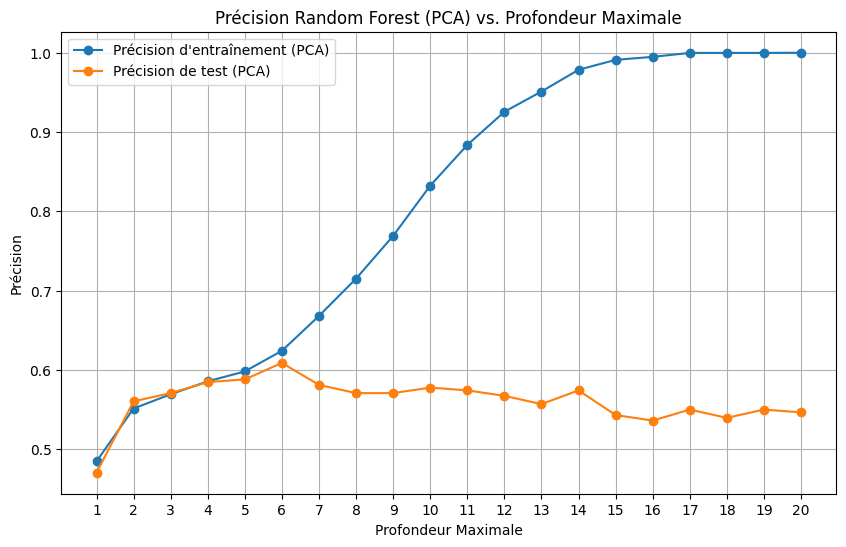

In [ ]:
train_accuracies_rf_pca = []
test_accuracies_rf_pca = []
max_depths_rf_pca = range(1, 21) # Itérer sur max_depth de 1 à 20

for depth in max_depths_rf_pca:
    # Initialiser le classifieur Random Forest temporaire avec la profondeur actuelle
    rf_classifier_pca_temp = RandomForestClassifier(n_estimators=60, max_depth=depth, bootstrap=True, random_state=42)
    rf_classifier_pca_temp.fit(X_train_pca_df, Y_train.values.ravel()) # Utiliser les données PCA

    y_train_pred_rf_pca_temp = rf_classifier_pca_temp.predict(X_train_pca_df)
    train_accuracies_rf_pca.append(accuracy_score(Y_train, y_train_pred_rf_pca_temp))

    y_test_pred_rf_pca_temp = rf_classifier_pca_temp.predict(X_test_pca_df)
    test_accuracies_rf_pca.append(accuracy_score(Y_test, y_test_pred_rf_pca_temp))

plt.figure(figsize=(10, 6))
plt.plot(max_depths_rf_pca, train_accuracies_rf_pca, label='Précision d\'entraînement (PCA)', marker='o')
plt.plot(max_depths_rf_pca, test_accuracies_rf_pca, label='Précision de test (PCA)', marker='o')
plt.title('Précision Random Forest (PCA) vs. Profondeur Maximale')
plt.xlabel('Profondeur Maximale')
plt.ylabel('Précision')
plt.xticks(max_depths_rf_pca)
plt.legend()
plt.grid(True)
plt.show()

Le meilleur résultat obtenu est :


max_depth=6

Ce résultat est gardé par la suite

#### Entraînement et évaluation du modèle Random Forest

In [ ]:
# Initialiser le classifieur Random Forest avec la meilleure profondeur maximale trouvée (PCA)
rf_classifier_pca = RandomForestClassifier(n_estimators=60, max_depth=6, bootstrap=True, random_state=42, class_weight=None)

# Entraîner le modèle en utilisant les données PCA
rf_classifier_pca.fit(X_train_pca_df, Y_train.values.ravel())



RandomForestClassifier(max_depth=6, n_estimators=60, random_state=42)

###Visualisation de l'arbre

Affichage des composantes principales de l'arbre de décision

In [ ]:
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_classifier_pca.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Importance des caractéristiques dans l'arbre de décision :")
display(feature_importances)

Importance des caractéristiques dans l'arbre de décision :


,Feature,Importance
0,ecart_pts_moyens,0.336280
6,ecart_pourcentage_etrangers,0.333542
8,h2h_dominance_ratio,0.057740
7,ecart_classement,0.050586
1,ecart_gd_recent,0.045461
5,ecart_age_moyen,0.045398
3,ecart_valeur_totale,0.040970
2,ecart_repos,0.034608
4,ecart_internationaux,0.032566
9,h2h_moyenne_buts,0.022848


### Prédiction sur le test

In [ ]:
y_test_pred_rf_pca = rf_classifier_pca.predict(X_test_pca_df)

### Evaluation du modèle

Accuracy (Random Forest avec PCA): 0.6090

Matrice de Confusion (Random Forest avec PCA):


,Prédit -1,Prédit 0,Prédit 1
Actuel -1,70,2,31
Actuel 0,24,4,39
Actuel 1,17,0,102


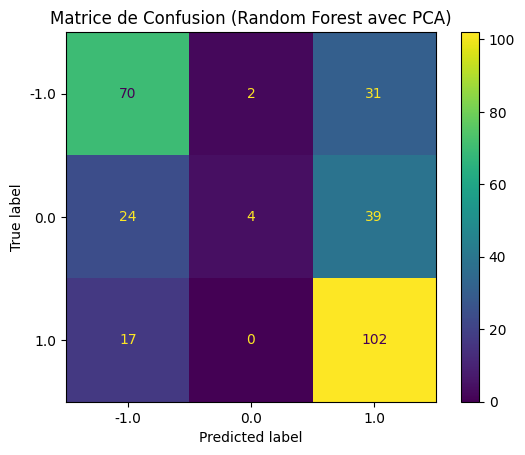

In [ ]:

# Évaluer le modèle
accuracy_rf_pca = accuracy_score(Y_test, y_test_pred_rf_pca)
conf_matrix_rf_pca = confusion_matrix(Y_test, y_test_pred_rf_pca)

print(f"Accuracy (Random Forest avec PCA): {accuracy_rf_pca:.4f}")

print("\nMatrice de Confusion (Random Forest avec PCA):")
display(pd.DataFrame(conf_matrix_rf_pca, index=['Actuel -1', 'Actuel 0', 'Actuel 1'], columns=['Prédit -1', 'Prédit 0', 'Prédit 1']))

cmd_display_rf_pca = ConfusionMatrixDisplay(conf_matrix_rf_pca, display_labels=rf_classifier_pca.classes_)
cmd_display_rf_pca.plot()
plt.title('Matrice de Confusion (Random Forest avec PCA)')
plt.show()

## SVM

In [ ]:
from sklearn.svm import SVC

svm_classifier_pca = SVC(random_state=42)
svm_classifier_pca.fit(X_train_pca_df, Y_train.values.ravel())

SVC(random_state=42)

### Prédiction sur le test avec SVM

In [ ]:
y_test_pred_svm_pca = svm_classifier_pca.predict(X_test_pca_df)

### Évaluation du modèle SVM

Accuracy (SVM avec PCA): 0.5744

Confusion Matrix (SVM avec PCA):


,Prédit -1,Prédit 0,Prédit 1
Actuel -1,62,9,32
Actuel 0,23,4,40
Actuel 1,12,7,100


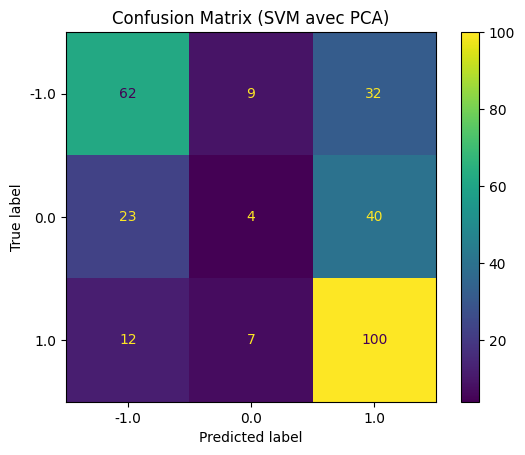

In [ ]:
# Calcul de la précision
accuracy_svm_pca = accuracy_score(Y_test, y_test_pred_svm_pca)
conf_matrix_svm_pca = confusion_matrix(Y_test, y_test_pred_svm_pca)

print(f"Accuracy (SVM avec PCA): {accuracy_svm_pca:.4f}")

print("\nConfusion Matrix (SVM avec PCA):")
display(pd.DataFrame(conf_matrix_svm_pca, index=['Actuel -1', 'Actuel 0', 'Actuel 1'], columns=['Prédit -1', 'Prédit 0', 'Prédit 1']))

cmd_display_svm_pca = ConfusionMatrixDisplay(conf_matrix_svm_pca, display_labels=svm_classifier_pca.classes_)
cmd_display_svm_pca.plot()
plt.title('Confusion Matrix (SVM avec PCA)')
plt.show()

### Amélioration du modèle SVM avec GridSearchCV

Pour améliorer la performance du modèle SVM, nous pouvons optimiser ses hyperparamètres. GridSearchCV nous permet de tester différentes combinaisons de paramètres (comme 'C' pour la régularisation et 'kernel' pour le type de noyau) pour trouver celle qui donne la meilleure précision.

Début de la recherche sur grille pour SVM...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Meilleurs hyperparamètres trouvés : {'C': 1, 'kernel': 'linear'}
Meilleur score de validation croisée : 0.5824667045319367

Accuracy (Meilleur SVM avec PCA): 0.6090

Matrice de Confusion (Meilleur SVM avec PCA):


,Prédit -1,Prédit 0,Prédit 1
Actuel -1,70,1,32
Actuel 0,25,5,37
Actuel 1,15,3,101


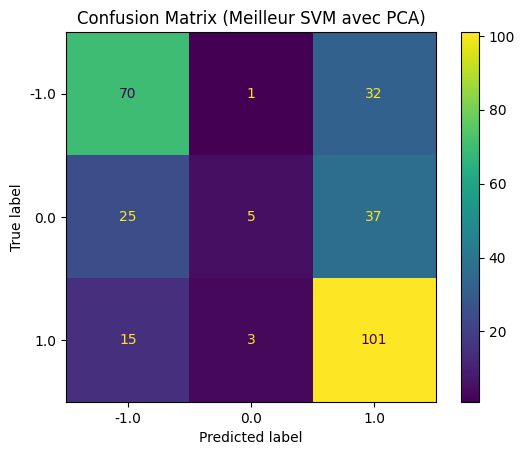

In [ ]:
from sklearn.model_selection import GridSearchCV

# Définir la grille des hyperparamètres à tester
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

# Initialiser GridSearchCV
# 'cv=3' signifie une validation croisée à 3 plis
# 'scoring=\'accuracy\'' signifie que nous optimisons la précision
# 'verbose=2' affiche plus d'informations pendant le processus
grid_search_svm = GridSearchCV(SVC(random_state=42), param_grid, cv=3, scoring='accuracy', verbose=2, n_jobs=-1)

# Exécuter la recherche sur grille sur les données d'entraînement PCA
print("Début de la recherche sur grille pour SVM...")
grid_search_svm.fit(X_train_pca_df, Y_train.values.ravel())

print("\nMeilleurs hyperparamètres trouvés :", grid_search_svm.best_params_)
print("Meilleur score de validation croisée :", grid_search_svm.best_score_)

# Utiliser le meilleur modèle trouvé par GridSearchCV
best_svm_classifier_pca = grid_search_svm.best_estimator_

# Prédiction sur l'ensemble de test avec le meilleur modèle
y_test_pred_best_svm_pca = best_svm_classifier_pca.predict(X_test_pca_df)

# Évaluation du meilleur modèle SVM
accuracy_best_svm_pca = accuracy_score(Y_test, y_test_pred_best_svm_pca)
conf_matrix_best_svm_pca = confusion_matrix(Y_test, y_test_pred_best_svm_pca)

print(f"\nAccuracy (Meilleur SVM avec PCA): {accuracy_best_svm_pca:.4f}")

print("\nMatrice de Confusion (Meilleur SVM avec PCA):")
display(pd.DataFrame(conf_matrix_best_svm_pca, index=['Actuel -1', 'Actuel 0', 'Actuel 1'], columns=['Prédit -1', 'Prédit 0', 'Prédit 1']))

cmd_display_best_svm_pca = ConfusionMatrixDisplay(conf_matrix_best_svm_pca, display_labels=best_svm_classifier_pca.classes_)
cmd_display_best_svm_pca.plot()
plt.title('Confusion Matrix (Meilleur SVM avec PCA)')
plt.show()

## KNN

### Préparation des données pour KNN (Scaling)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Créer des copies des DataFrames originaux pour KNN (Y_train et Y_test sont déjà prêts)
Y_train_knn = Y_train.copy()
Y_test_knn = Y_test.copy()

# Utiliser directement les données PCA pour KNN
X_train_knn_scaled = X_train_pca_df.copy() # Assign PCA data
X_test_knn_scaled = X_test_pca_df.copy() # Assign PCA data

print("Données d'entraînement et de test pour KNN utilisant les composantes principales de l'ACP.")

Données d'entraînement et de test pour KNN utilisant les composantes principales de l'ACP.


### Entraînement du modèle KNN

Je recherche le meilleur nombre de voisins pour le KNN

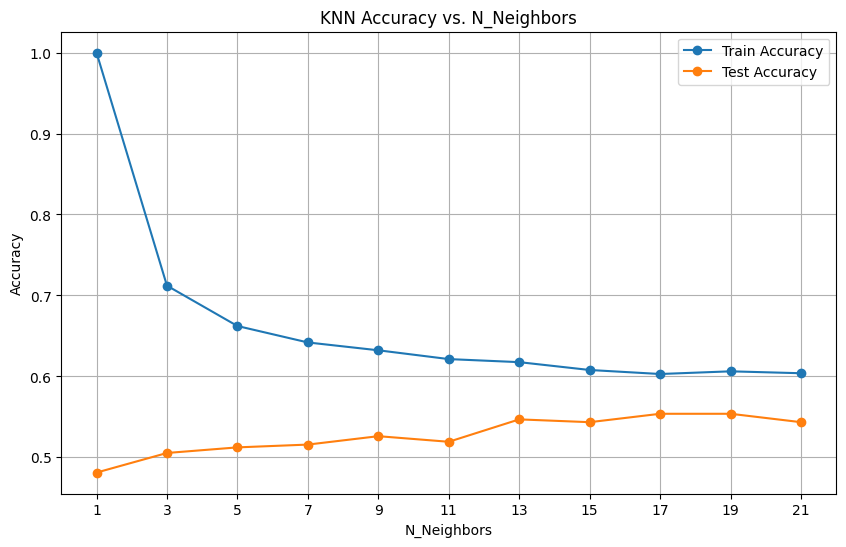

In [ ]:
train_accuracies_knn = []
test_accuracies_knn = []
n_neighbors_range = range(1, 22, 2) # Nombres impairs de 1 à 21

for n in n_neighbors_range:
    knn_classifier_temp = KNeighborsClassifier(n_neighbors=n)
    knn_classifier_temp.fit(X_train_knn_scaled, Y_train_knn.values.ravel())

    y_train_pred_knn_temp = knn_classifier_temp.predict(X_train_knn_scaled)
    train_accuracies_knn.append(accuracy_score(Y_train_knn, y_train_pred_knn_temp))

    y_test_pred_knn_temp = knn_classifier_temp.predict(X_test_knn_scaled)
    test_accuracies_knn.append(accuracy_score(Y_test_knn, y_test_pred_knn_temp))

plt.figure(figsize=(10, 6))
plt.plot(n_neighbors_range, train_accuracies_knn, label='Train Accuracy', marker='o')
plt.plot(n_neighbors_range, test_accuracies_knn, label='Test Accuracy', marker='o')
plt.title('KNN Accuracy vs. N_Neighbors')
plt.xlabel('N_Neighbors')
plt.ylabel('Accuracy')
plt.xticks(list(n_neighbors_range))
plt.legend()
plt.grid(True)
plt.show()


Le meilleur nombre de voisins est 17, je garde cette valeur.

Test de différents nombres de valeurs données par l'acp

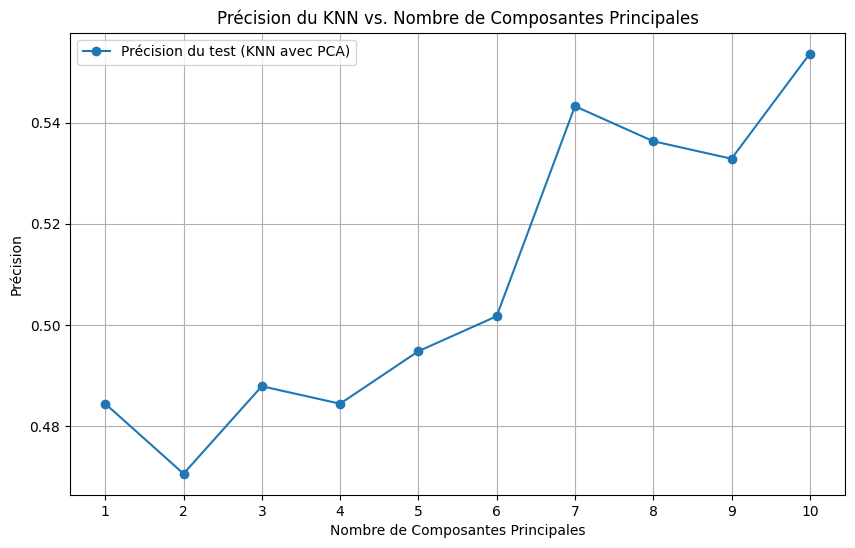

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

accuracies_knn_pca_components = []
num_components_range = range(1, 11) # Tester avec 1 à 10 composantes principales

# Utiliser le meilleur n_neighbors trouvé précédemment (17)
optimal_n_neighbors = 17

for n_comp in num_components_range:
    # Sélectionner les n_comp premières composantes principales
    X_train_pca_subset = X_train_pca_df.iloc[:, :n_comp]
    X_test_pca_subset = X_test_pca_df.iloc[:, :n_comp]

    # Initialiser et entraîner le classificateur KNN avec le sous-ensemble de composantes PCA
    knn_classifier_pca_temp = KNeighborsClassifier(n_neighbors=optimal_n_neighbors)
    knn_classifier_pca_temp.fit(X_train_pca_subset, Y_train_knn.values.ravel())

    # Prédire sur l'ensemble de test
    y_test_pred_knn_pca_temp = knn_classifier_pca_temp.predict(X_test_pca_subset)

    # Calculer et stocker la précision
    accuracy = accuracy_score(Y_test_knn, y_test_pred_knn_pca_temp)
    accuracies_knn_pca_components.append(accuracy)

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.plot(num_components_range, accuracies_knn_pca_components, label='Précision du test (KNN avec PCA)', marker='o')
plt.title('Précision du KNN vs. Nombre de Composantes Principales')
plt.xlabel('Nombre de Composantes Principales')
plt.ylabel('Précision')
plt.xticks(list(num_components_range))
plt.legend()
plt.grid(True)
plt.show()

LE KNN donne de meilleurs résultats en gardant chaque résultats de l'acp.

In [ ]:
# Initialiser le classifieur KNN (vous pouvez ajuster n_neighbors)
knn_classifier = KNeighborsClassifier(n_neighbors=17)

# Entraîner le modèle
knn_classifier.fit(X_train_knn_scaled, Y_train_knn.values.ravel())


KNeighborsClassifier(n_neighbors=17)

### Prédiction sur le test avec KNN

In [ ]:
y_test_pred_knn = knn_classifier.predict(X_test_knn_scaled)


### Évaluation du modèle KNN

Accuracy (KNN): 0.5536

Confusion Matrix (KNN):


,Predicted -1,Predicted 0,Predicted 1
Actual -1,61,14,28
Actual 0,25,11,31
Actual 1,12,19,88


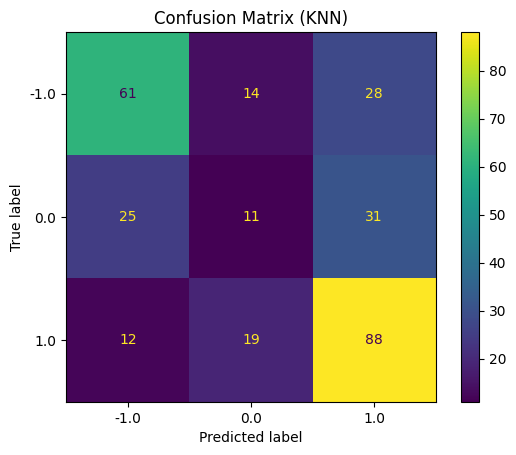

In [ ]:
# Calcul de la précision
accuracy_knn = accuracy_score(Y_test_knn, y_test_pred_knn)
conf_matrix_knn = confusion_matrix(Y_test_knn, y_test_pred_knn)

print(f"Accuracy (KNN): {accuracy_knn:.4f}")

print("\nConfusion Matrix (KNN):")
display(pd.DataFrame(conf_matrix_knn, index=['Actual -1', 'Actual 0', 'Actual 1'], columns=['Predicted -1', 'Predicted 0', 'Predicted 1']))

cmd_display_knn = ConfusionMatrixDisplay(conf_matrix_knn, display_labels=knn_classifier.classes_)
cmd_display_knn.plot()
plt.title('Confusion Matrix (KNN)')
plt.show()


## Descente de gradient

### Implémentation du modèle de régression logistique (Descente de Gradient)

Modèle de régression logistique entraîné avec PCA.

Accuracy (Logistic Regression avec PCA): 0.5917

Confusion Matrix (Logistic Regression avec PCA):


,Predicted -1,Predicted 0,Predicted 1
Actual -1,69,0,34
Actual 0,22,0,45
Actual 1,17,0,102


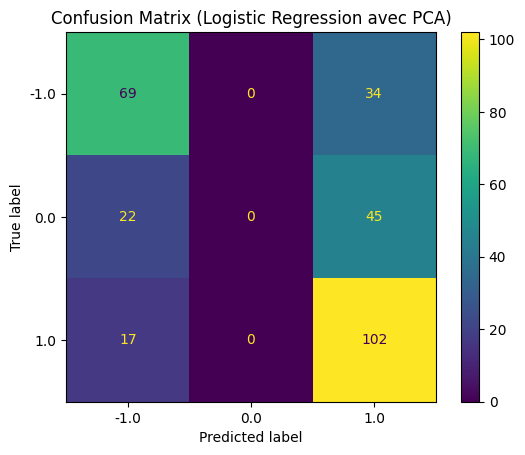

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialiser le classifieur de régression logistique
log_reg_classifier = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

# Entraîner le modèle en utilisant les données PCA
log_reg_classifier.fit(X_train_pca_df, Y_train.values.ravel())

print("Modèle de régression logistique entraîné avec PCA.")

# Prédiction sur le test avec la régression logistique (données PCA)
y_test_pred_log_reg = log_reg_classifier.predict(X_test_pca_df)

# Évaluation du modèle de régression logistique
accuracy_log_reg = accuracy_score(Y_test, y_test_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(Y_test, y_test_pred_log_reg)

print(f"\nAccuracy (Logistic Regression avec PCA): {accuracy_log_reg:.4f}")

print("\nConfusion Matrix (Logistic Regression avec PCA):")
display(pd.DataFrame(conf_matrix_log_reg, index=['Actual -1', 'Actual 0', 'Actual 1'], columns=['Predicted -1', 'Predicted 0', 'Predicted 1']))

cmd_display_log_reg = ConfusionMatrixDisplay(conf_matrix_log_reg, display_labels=log_reg_classifier.classes_)
cmd_display_log_reg.plot()
plt.title('Confusion Matrix (Logistic Regression avec PCA)')
plt.show()

## Récapitulatif

In [ ]:
import pandas as pd

# Create a dictionary to store the results
results_data = {
    'Modèle': ['Random Forest', 'SVM', 'SVM (Optimized)', 'KNN', 'Logistic Regression'],
    'Accuracy': [
        accuracy_rf_pca,
        accuracy_svm_pca,
        accuracy_best_svm_pca,
        accuracy_knn,
        accuracy_log_reg
    ],
    'Matrice de Confusion (Simplifiée)': [
        f"Correctly predicted 1: {conf_matrix_rf_pca[2,2]}, 0: {conf_matrix_rf_pca[1,1]}, -1: {conf_matrix_rf_pca[0,0]}",
        f"Correctly predicted 1: {conf_matrix_svm_pca[2,2]}, 0: {conf_matrix_svm_pca[1,1]}, -1: {conf_matrix_svm_pca[0,0]}",
        f"Correctly predicted 1: {conf_matrix_best_svm_pca[2,2]}, 0: {conf_matrix_best_svm_pca[1,1]}, -1: {conf_matrix_best_svm_pca[0,0]}",
        f"Correctly predicted 1: {conf_matrix_knn[2,2]}, 0: {conf_matrix_knn[1,1]}, -1: {conf_matrix_knn[0,0]}",
        f"Correctly predicted 1: {conf_matrix_log_reg[2,2]}, 0: {conf_matrix_log_reg[1,1]}, -1: {conf_matrix_log_reg[0,0]}"
    ]
}

# Create the DataFrame
results_df = pd.DataFrame(results_data)

# Display the results table
display(results_df)

,Modèle,Accuracy,Matrice de Confusion (Simplifiée)
0,Random Forest,0.608997,"Correctly predicted 1: 102, 0: 4, -1: 70"
1,SVM,0.574394,"Correctly predicted 1: 100, 0: 4, -1: 62"
2,SVM (Optimized),0.608997,"Correctly predicted 1: 101, 0: 5, -1: 70"
3,KNN,0.553633,"Correctly predicted 1: 88, 0: 11, -1: 61"
4,Logistic Regression,0.591696,"Correctly predicted 1: 102, 0: 0, -1: 69"


Les meilleurs résultats sont données par le Random forest et le SVM, je garde les résultats du Random forest.

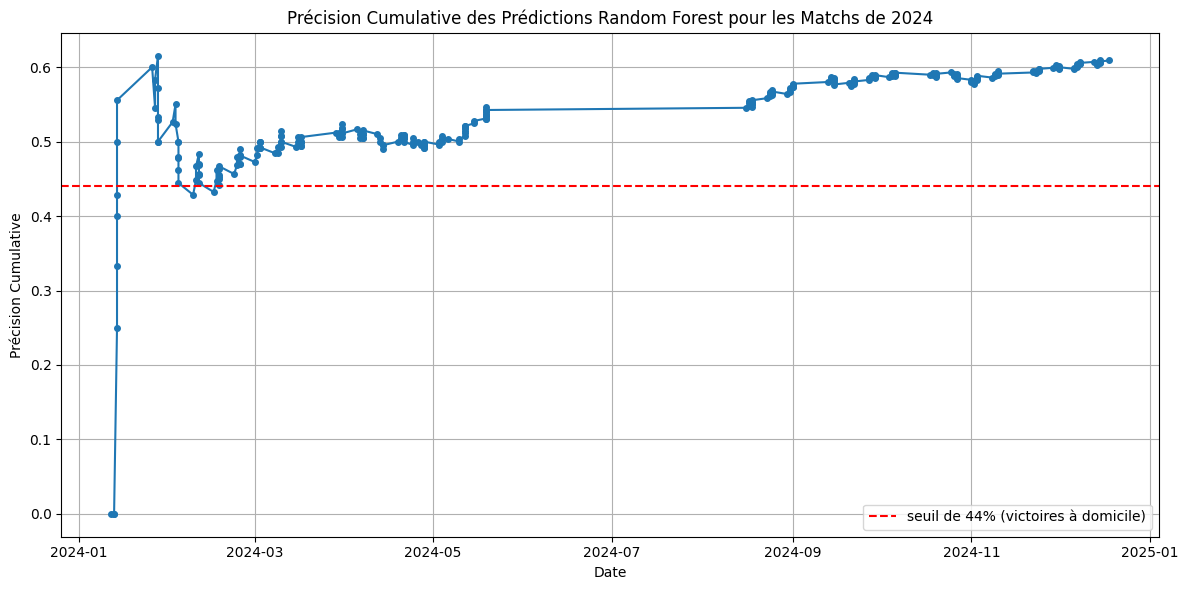

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score

# Obtenir les prédictions pour l'ensemble de test 2024 en utilisant le classifieur rf_classifier_pca entraîné
y_test_pred_rf_pca = rf_classifier_pca.predict(X_test_pca_df)

# Créer un DataFrame pour stocker les résultats réels, prédits et les dates pour 2024
# Nous avons besoin des dates originales de df_final pour la période X_test

df_2024_results = df_final[df_final['date'] >= "2024-01-01"].copy()
df_2024_results = df_2024_results[df_2024_results['date'] < "2025-01-01"].copy()

df_2024_results['actual'] = Y_test.values
df_2024_results['predicted'] = y_test_pred_rf_pca

# Trier par date pour calculer la précision cumulative
df_2024_results = df_2024_results.sort_values(by='date').reset_index(drop=True)

# Calculer les prédictions correctes
df_2024_results['correct'] = (df_2024_results['actual'] == df_2024_results['predicted']).astype(int)

# Calculer les prédictions correctes cumulées et le total des prédictions cumulées
df_2024_results['cumulative_correct'] = df_2024_results['correct'].cumsum()
df_2024_results['cumulative_total'] = range(1, len(df_2024_results) + 1)

# Calculer la précision cumulative
df_2024_results['cumulative_accuracy'] = df_2024_results['cumulative_correct'] / df_2024_results['cumulative_total']

# Tracer
plt.figure(figsize=(12, 6))
plt.plot(df_2024_results['date'], df_2024_results['cumulative_accuracy'], marker='o', linestyle='-', markersize=4)
plt.axhline(y=0.44, color='r', linestyle='--', label='seuil de 44% (victoires à domicile)')
plt.title('Précision Cumulative des Prédictions Random Forest pour les Matchs de 2024')
plt.xlabel('Date')
plt.ylabel('Précision Cumulative')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

La précision moyenne ne baisse pas au fil du temps mais augmente ce qui peu sembler surprenant mais étant donné que certaines entrées comme le classement ne reflète que les performance de la saison précédante, on peut s'attendre à ce que en fin d'année le score de dominance et les données H2H permettent de garder une bonne précision.

## Predire Y test

Le meilleur résultat étant donnée par le random forest, je fait la prédiction des matchs de 2025 avec ce même random forest, cependant cette fois j'inclu les matchs de 2024 dans l'entrainement.

In [ ]:
X_train_full = df_final[df_final['date'] < "2025-01-01"].copy()
Y_train_full = X_train_full['target_results'].copy()
X_train_full = X_train_full.drop(columns = ['date', 'game_id', 'target_results'])

X_test_2025 = df_final[df_final['date'] >= "2025-01-01"].copy()
game_ids_2025 = X_test_2025['game_id'].copy()
X_test_2025 = X_test_2025.drop(columns = ['date', 'game_id', 'target_results'])

In [ ]:
# Réentrainement avec les matchs jusqu'à 2024
rf_classifier_pca.fit(X_train_full, Y_train_full)

# prédiction des match de 2025
y_pred_2025 = rf_classifier_pca.predict(X_test_2025)

# Create predictions_df here as it was defined in a later cell
predictions_df = pd.DataFrame({'game_id': game_ids_2025, 'results': y_pred_2025.astype(int)})

print(predictions_df.head())

      game_id  results
4521  4363886        1
4522  4363883        1
4523  4363879        1
4524  4363881       -1
4525  4363882        1


Export des données

In [ ]:
predictions_df = pd.DataFrame({'game_id': game_ids_2025, 'results': y_pred_2025.astype(int)})
predictions_df.to_csv('predictions_2025.csv', index=False)